# Planning and Learning with Tabular Methods

Following **Chapter 8** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [2]:
import random
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

from util.envs import GridMazeEnv, Action, State

In [3]:
def initialize_Q_pi(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict:
    
    Q = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                Q[s] = np.zeros(len(actions)) # zeros Q(terminal, all_a)
                continue
            Q[s] = -np.random.random(len(actions)) # arbitrary Q(s, a)
    return Q

def initialize_model(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict[tuple[State, Action], Optional[tuple[float, State]]]:
    """
    Returns:
        dict[tuple[State, Action], Optional[tuple[State, float]]]: keys are (s, a) pairs; values are (r, s') or None
    """
    
    model = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                continue
            for a in actions:
                model_key = (s, a)
                model[model_key] = None
    return model


def pi_epsilon_greedy(s: tuple[int, int], Q_pi: dict | tuple[dict, dict], epsilon: float) -> int:
    p = np.random.random()
    
    if isinstance(Q_pi, dict): # Regular
        Q_pi_s = Q_pi[s]
    elif isinstance(Q_pi, tuple): # Double learning
        Q_pi_s = Q_pi[0][s] + Q_pi[1][s] # action via addition from the 2 value functions

    if p < epsilon: # explore
        return int(np.random.randint(len(Q_pi_s)))
    return int(np.argmax(Q_pi_s)) # exploit

### Dyna-Q

Page *161*, chapter *8.2*

In [4]:
maze_grid = np.array([
    [0, 0, 0, 0, 0, 0, 0, 1, 3],
    [0, 0, 1, 0, 0, 0, 0, 1, 0],
    [2, 0, 1, 0, 0, 0, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0],
])

maze_env = GridMazeEnv(maze_grid)
maze_env

[[□ □ □ □ □ □ □ ■ G]
 [□ □ ■ □ □ □ □ ■ □]
 [S □ ■ □ □ □ □ ■ □]
 [□ □ ■ □ □ □ □ □ □]
 [□ □ □ □ □ □ □ □ □]
 [□ □ □ □ □ ■ □ □ □]]

In [5]:
def run_dyna_q(env: GridMazeEnv, n: int, gamma: float, alpha: float, num_epochs: int) -> tuple[dict, dict]:
    Q_pi: dict = initialize_Q_pi(env.num_rows, env.num_cols, env.goal_position, env.action_set)
    model: dict = initialize_model(env.num_rows, env.num_cols, env.goal_position, env.action_set)
    metrics = {
        "episode_lengths": []
    }

    observed_sa: set[tuple[State, Action]] = set()
    for epoch in tqdm(range(num_epochs)):
        step = 0
        epsilon = max(0.1, 1 / (epoch + 1)) # decaying epsilon

        s = env.reset()
        while True:
            # --- direct rl ---
            a_idx = pi_epsilon_greedy(s, Q_pi, epsilon)
            a = env.action_set[a_idx]

            r, s_prime, done = env.step(a)

            target = r + gamma * max(Q_pi[s_prime]) # Q-learning target
            error =  target - Q_pi[s][a_idx] # Q-learning error
            Q_pi[s][a_idx] += alpha * error # Update
            
            model[(s, a)] = (r, s_prime) # Update model - assumes deterministic world
            observed_sa.add((s, a)) # Store observed (s, a) for more efficient model querying (unique in basic Dyna-Q - using set)

            s = s_prime
            step += 1
            if done:
                break

            # --- planning ---
            observed_sa_list = list(observed_sa)
            for _ in range(n):
                s_sampled, a_sampled = random.choice(observed_sa_list)
                a_sampled_idx = env.action_set.index(a_sampled)
                r_modelled, s_prime_modelled = model[(s_sampled, a_sampled)] # Use model to 'predict' what r and s' would be

                planning_target = r_modelled + gamma * max(Q_pi[s_prime_modelled]) # Q-learning target (planning)
                planning_error = planning_target - Q_pi[s_sampled][a_sampled_idx] # Q-learning error (planning)
                Q_pi[s_sampled][a_sampled_idx] += alpha * planning_error # Update (planning)

        metrics["episode_lengths"].append(step)

    return Q_pi, metrics

In [6]:
gamma = 0.9 # discounting
alpha = 0.1 # step size
n = 25 # planning steps
num_epochs = 50

Q_pi, metrics = run_dyna_q(maze_env, n, gamma, alpha, num_epochs)

100%|██████████| 50/50 [00:00<00:00, 623.44it/s]


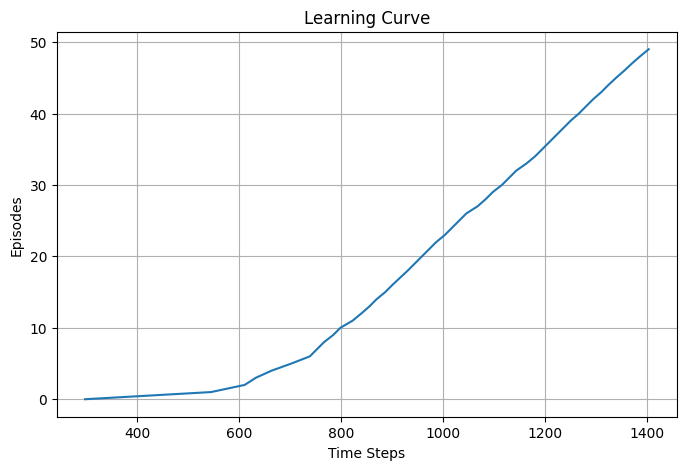

In [7]:
maze_env.plot_time_steps_per_episode(metrics["episode_lengths"])

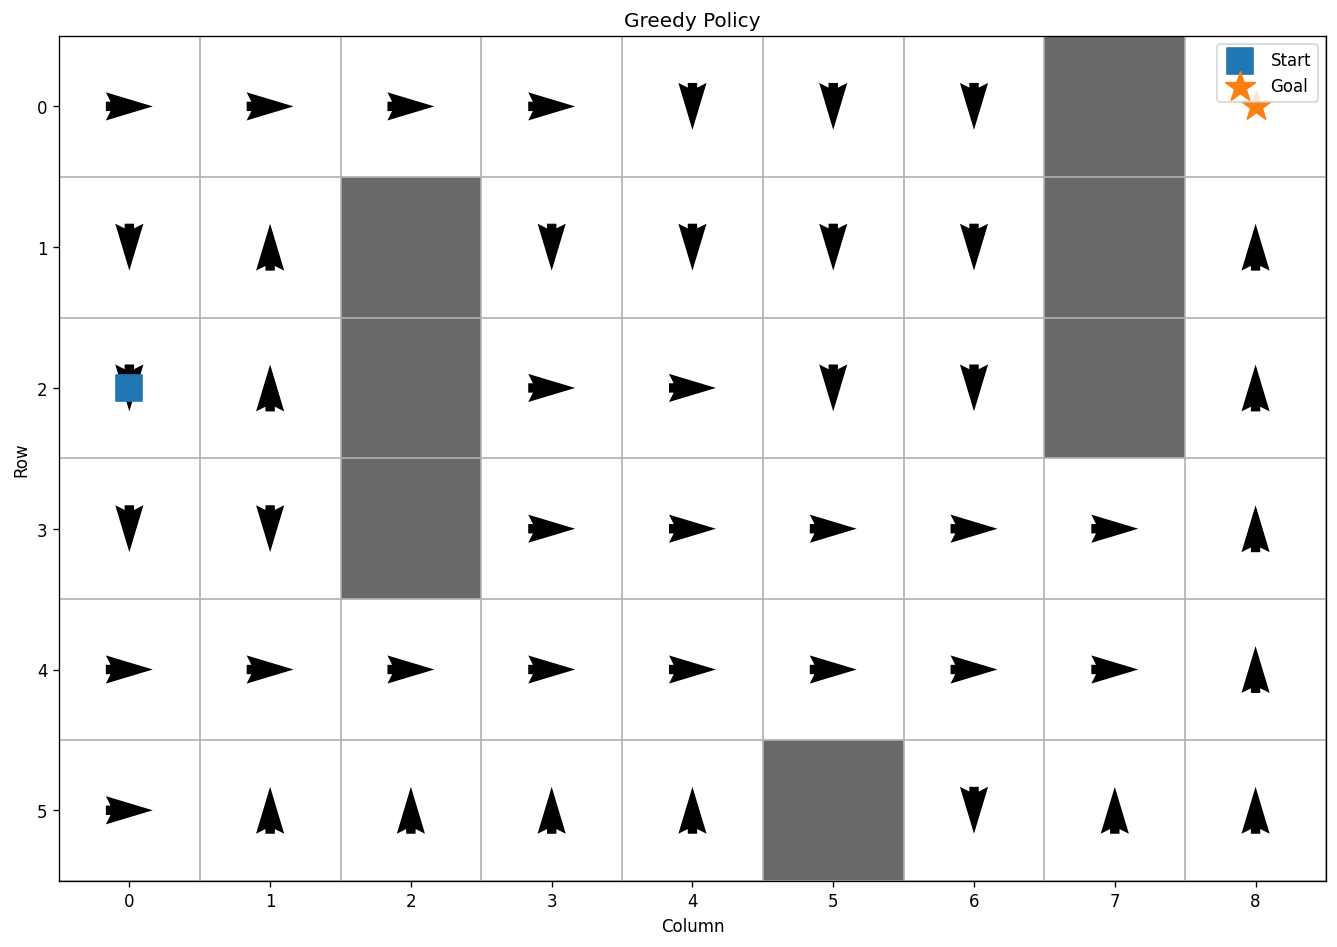

In [8]:
maze_env.plot_policy(Q_pi, maze_env.action_set)

In [14]:
_ = maze_env.animate_episode_with_trail(Q_pi, maze_env.action_set, starting_state=(0, 0))

Comparison across varying n values for planning.

In [15]:
# Compare DYNA-Q performance across varying numbers of planning steps.
gamma = 0.9 # discounting
alpha = 0.1 # step size
num_epochs = 50
n_values = [0, 1, 2, 5, 10, 20, 50]

comparison = {
    "n": [],
    "mean_length": [],
    "median_length": [],
    "final_length": [],
}
episode_trajectories = {}

for n in n_values:
    _, metrics = run_dyna_q(maze_env, n, gamma, alpha, num_epochs)
    lengths = np.array(metrics["episode_lengths"])
    comparison["n"].append(n)
    comparison["mean_length"].append(lengths.mean())
    comparison["median_length"].append(np.median(lengths))
    comparison["final_length"].append(lengths[-1])
    episode_trajectories[n] = lengths

100%|██████████| 50/50 [00:00<00:00, 268.92it/s]


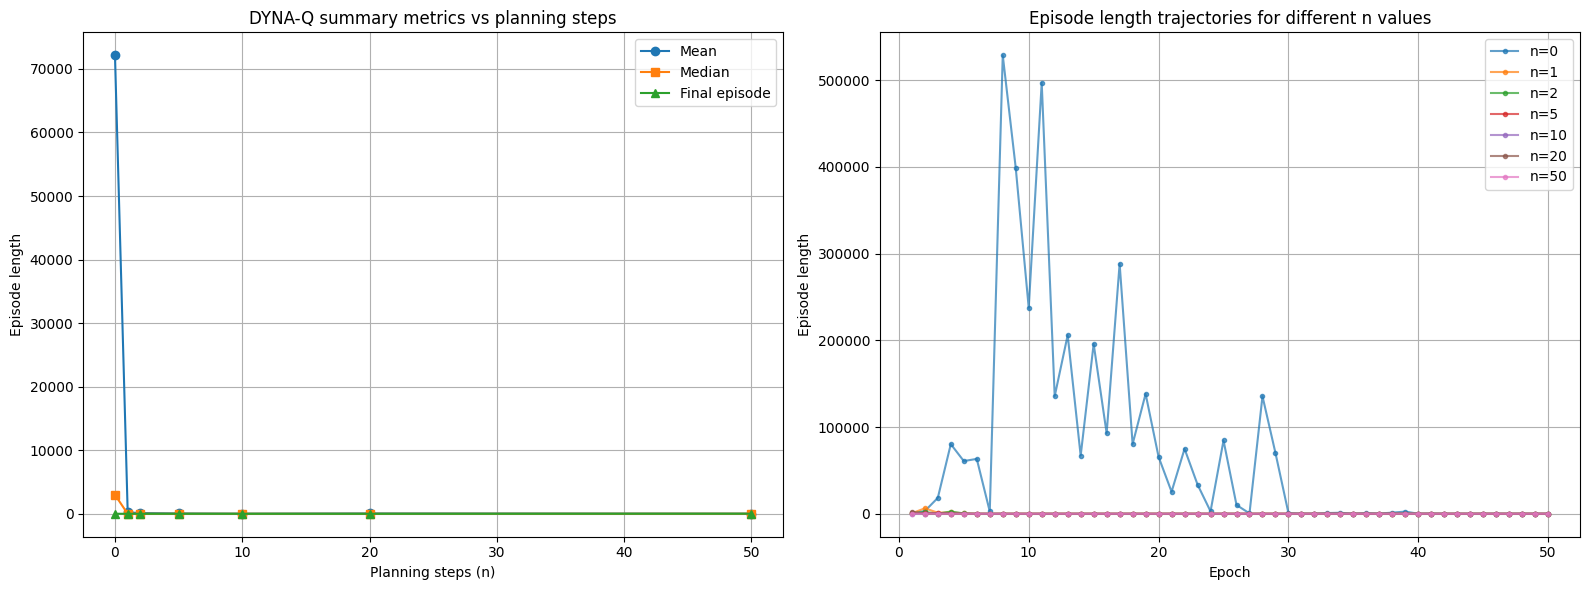

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(comparison["n"], comparison["mean_length"], marker="o", label="Mean")
axes[0].plot(comparison["n"], comparison["median_length"], marker="s", label="Median")
axes[0].plot(comparison["n"], comparison["final_length"], marker="^", label="Final episode")
axes[0].set_xlabel("Planning steps (n)")
axes[0].set_ylabel("Episode length")
axes[0].set_title("DYNA-Q summary metrics vs planning steps")
axes[0].legend()
axes[0].grid(True)

for n in n_values:
    axes[1].plot(
        range(1, len(episode_trajectories[n]) + 1),
        episode_trajectories[n],
        marker=".",
        alpha=0.7,
        label=f"n={n}",
    )

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Episode length")
axes[1].set_title("Episode length trajectories for different n values")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Dyna-Q+

Page *168*, chapter *8.3*

In [22]:
def initialize_model_dyna_q_plus(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict[tuple[State, Action], Optional[tuple[float, State]]]:
    """
    Returns:
        dict[tuple[State, Action], Optional[tuple[State, float]]]: keys are (s, a) pairs; values are (r, s') or None
    """
    
    model = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                continue
            for a in actions:
                model[(s, a)] = (0.0, s)
    return model

def initialize_model_tau(
    env_num_rows: int, 
    env_num_cols: int, 
    env_goal: tuple[int, int], 
    actions: tuple[Action, ...]
    ) -> dict[tuple[State, Action], int]:
    """
    Initialize tau for the Dyna-Q+ agent. This represents how many timesteps have elapsed since any given (s, a) pair
    was last tried in a real interaction with the environment.

    Returns:
        dict[tuple[State, Action], Optional[tuple[State, float]]]: keys are (s, a) pairs; values are int
    """
    
    model = {}
    for row in range(env_num_rows):
        for col in range(env_num_cols):
            s = (row, col)
            if s == env_goal:
                continue
            for a in actions:
                model[(s, a)] = 0
    return model

def update_tau(tau: dict[tuple[State, Action], int], last_visited: tuple[State, Action]):
    """Increment all (s, a) pairs and reset the last visited pair."""
    for key in tau.keys():
        tau[key] += 1
    tau[last_visited] = 0

In [27]:
def run_dyna_q_plus(env: GridMazeEnv, n: int, gamma: float, alpha: float, k: float, num_epochs: int) -> tuple[dict, dict]:
    Q_pi: dict = initialize_Q_pi(env.num_rows, env.num_cols, env.goal_position, env.action_set)
    model: dict = initialize_model_dyna_q_plus(env.num_rows, env.num_cols, env.goal_position, env.action_set)
    tau: dict = initialize_model_tau(env.num_rows, env.num_cols, env.goal_position, env.action_set)
    metrics = {
        "episode_lengths": []
    }

    all_sa = list(model.keys()) # all state-action pairs
    for epoch in tqdm(range(num_epochs)):
        step = 0
        epsilon = max(0.1, 1 / (epoch + 1)) # decaying epsilon

        s = env.reset()
        while True:
            # --- direct rl ---
            a_idx = pi_epsilon_greedy(s, Q_pi, epsilon)
            a = env.action_set[a_idx]

            r, s_prime, done = env.step(a)

            target = r + gamma * max(Q_pi[s_prime]) # Q-learning target
            error =  target - Q_pi[s][a_idx] # Q-learning error
            Q_pi[s][a_idx] += alpha * error # Update
            
            model[(s, a)] = (r, s_prime) # Update model - assumes deterministic world
            update_tau(tau, (s, a)) # Update tau for Dyna-Q+

            # --- planning ---
            for _ in range(n):
                s_sampled, a_sampled = random.choice(all_sa)
                a_sampled_idx = env.action_set.index(a_sampled)
                r_modelled, s_prime_modelled = model[(s_sampled, a_sampled)] # Use model to 'predict' what r and s' would be
                r_modelled += k * np.sqrt(tau[(s_sampled, a_sampled)]) # Increase reward depending on how long ago this (s, a) was last experienced (via real experience) - Dyna-Q+

                planning_target = r_modelled + gamma * max(Q_pi[s_prime_modelled]) # Q-learning target (planning)
                planning_error = planning_target - Q_pi[s_sampled][a_sampled_idx] # Q-learning error (planning)
                Q_pi[s_sampled][a_sampled_idx] += alpha * planning_error # Update (planning)

            # --- housekeeping ---
            s = s_prime
            step += 1
            if done:
                break

        metrics["episode_lengths"].append(step)

    return Q_pi, metrics

In [30]:
gamma = 0.9 # discounting
alpha = 0.1 # step size
n = 25 # planning steps
k = 1e-4 # reward multiplier for Dyna-Q+
num_epochs = 50

Q_pi_dqp, metrics_dqp = run_dyna_q_plus(maze_env, n, gamma, alpha, k, num_epochs)

100%|██████████| 50/50 [00:00<00:00, 213.90it/s]


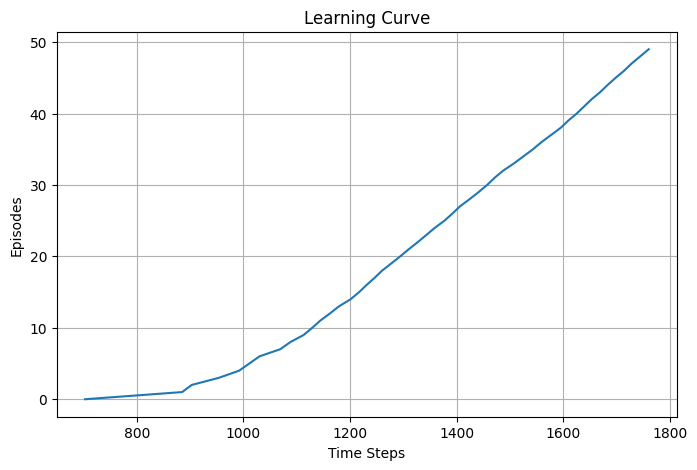

In [31]:
maze_env.plot_time_steps_per_episode(metrics_dqp["episode_lengths"])

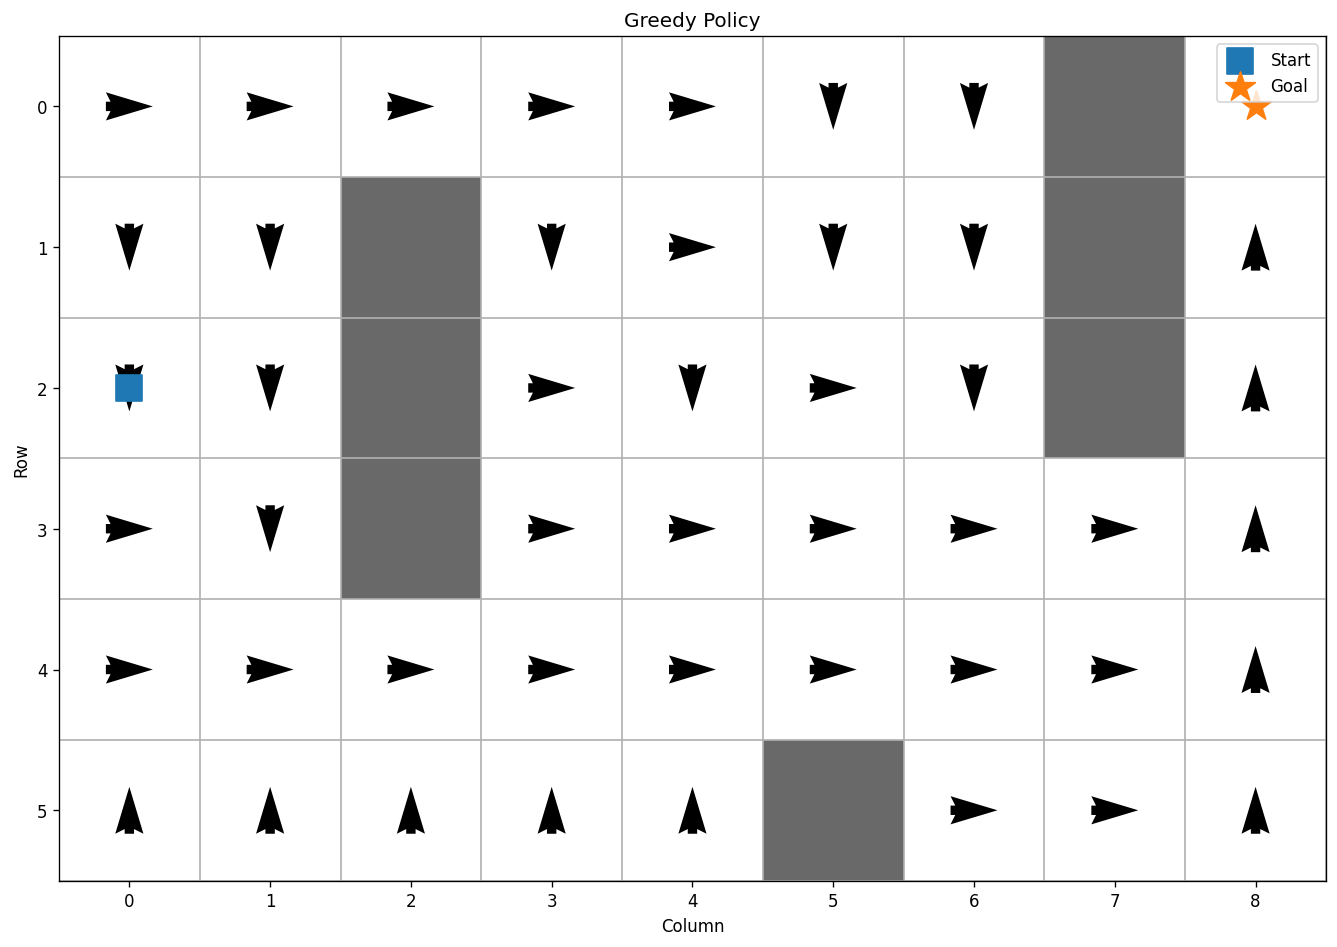

In [32]:
maze_env.plot_policy(Q_pi_dqp, maze_env.action_set)

In [33]:
_ = maze_env.animate_episode_with_trail(Q_pi_dqp, maze_env.action_set, starting_state=(0, 0))

### Dyna-Q and Dyna-Q+ comparison

In [36]:
def cumulative_learning_curve(metrics):
    """
    Convert episode lengths into:
        x = cumulative time steps
        y = episodes completed
    """
    episode_lengths = np.array(metrics["episode_lengths"])

    x = np.cumsum(episode_lengths)
    y = np.arange(1, len(episode_lengths) + 1)

    return x, y

In [37]:
gamma = 0.9
alpha = 0.1
n = 25
num_epochs = 50

# Dyna-Q
Q_dq, metrics_dq = run_dyna_q(
    env=maze_env,
    n=n,
    gamma=gamma,
    alpha=alpha,
    num_epochs=num_epochs
)

# Dyna-Q+
Q_dqp, metrics_dqp = run_dyna_q_plus(
    env=maze_env,
    n=n,
    gamma=gamma,
    alpha=alpha,
    k=1e-4,
    num_epochs=num_epochs
)

100%|██████████| 50/50 [00:00<00:00, 181.40it/s]


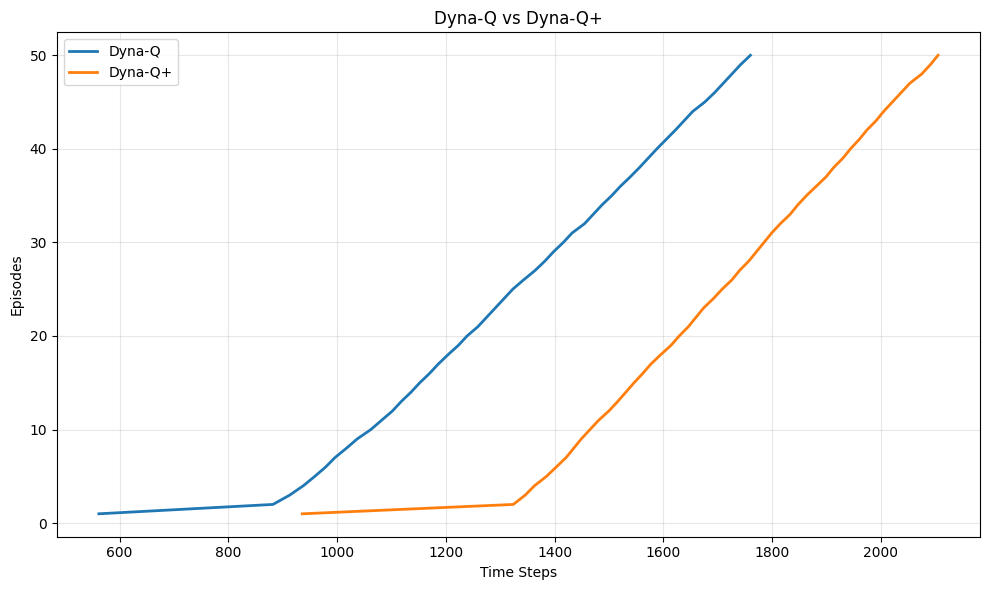

In [38]:
x_dq, y_dq = cumulative_learning_curve(metrics_dq)
x_dqp, y_dqp = cumulative_learning_curve(metrics_dqp)

plt.figure(figsize=(10, 6))
plt.plot(
    x_dq,
    y_dq,
    linewidth=2,
    label="Dyna-Q"
)
plt.plot(
    x_dqp,
    y_dqp,
    linewidth=2,
    label="Dyna-Q+"
)
plt.xlabel("Time Steps")
plt.ylabel("Episodes")
plt.title("Dyna-Q vs Dyna-Q+")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Dyna-2

2008. David Silver, Richard Sutton, and Martin Müller, <i>Sample-Based Learning and Search with Permanent and Transient Memories</i> ; Link: https://dl.acm.org/doi/pdf/10.1145/1390156.1390278